# Inflow & MOFA-Flex: Spatially-Resolved Cell-Cell Communication Programs

## Overview

This tutorial demonstrates how to integrate **inflow score** with **MOFA-Flex** to extract spatially-resolved, single-cell derived communication programs from mouse brain tissue. 

For a detailed walkthrough of the inflow score itself, please see our tutorial: [Inferring Cell–Cell Interactions at Single Cell Resolution](https://github.com/scverse/liana-py/blob/main/docs/notebooks/inflow_score.ipynb).

For more information about [MOFA-Flex](https://www.biorxiv.org/content/10.1101/2025.11.03.686250v1), please visit their [documentation](https://mofaflex.readthedocs.io/stable/).

<img src="inflow_mofaflex.png" width=800 />

---

## Load Packages

> **Note:** This tutorial uses the MOFA-Flex `0.2.0` API, which is not yet released on PyPI. Install the development version from GitHub:
>
> ```bash
> pip install "mofaflex @ git+https://github.com/bioFAM/mofaflex.git@main"
> ```

In [1]:
import os

# --- Reproducibility on GPU ---
# `fit(seed=...)` seeds MOFA-Flex's initialization and minibatch order, but PyTorch's default
# CUDA kernels for the SVI gradient reductions (atomic-add scatter/index_add) sum in a
# non-deterministic order. That drift compounds over training and, on real data with many
# closely-competing factors, is enough to shuffle factor identity/ordering run-to-run *despite
# the seed*. Forcing deterministic algorithms removes it, making same-GPU training bitwise
# reproducible. `CUBLAS_WORKSPACE_CONFIG` must be set before torch is first imported.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import warnings

import anndata as ad
import numpy as np
import pandas as pd
import torch

torch.use_deterministic_algorithms(True)

import liana as li
import mofaflex as mfl
import squidpy as sq
import decoupler as dc

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import scanpy as sc

from anndata._warnings import ImplicitModificationWarning
warnings.filterwarnings("ignore", category=ImplicitModificationWarning)

# Embed inline figures as JPEG (not the 2x retina PNG default) so the rendered notebook stays small
sc.set_figure_params(dpi=80, dpi_save=200, facecolor="white", ipython_format='jpeg')

# Select the fastest available device for MOFA-Flex training: CUDA > CPU.
# MPS (Apple Silicon) is not usable with the current MOFA-Flex development version: its
# likelihoods allocate float64 tensors and its GP prior calls `torch.pdist`, neither of which
# the MPS backend supports, so Apple Silicon falls back to CPU.
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"Using device: {device}")

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



Using device: cpu


## Load and Prep Data

To demonstrate the integration in practice, we reuse the same spatial transcriptomics dataset as the [inflow score tutorial](https://github.com/scverse/liana-py/blob/main/docs/notebooks/inflow_score.ipynb): a MERFISH dataset from [*A molecularly defined and spatially resolved cell atlas of the whole mouse brain* (Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9); [WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).

In [2]:
adata = li.ds.yao_2023()

In [3]:
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"].copy()
adata.var_names = adata.var["gene_name"]

# The spatial coordinates load as float64. MPS (Apple Silicon) does not support float64,
# so we cast them to float32 here. This propagates downstream into the MuData used to train
# MOFA-Flex, letting its Gaussian Process prior (which reads these coordinates) run on MPS.
adata.obsm["X_spatial_coords"] = adata.obsm["X_spatial_coords"].astype("float32")

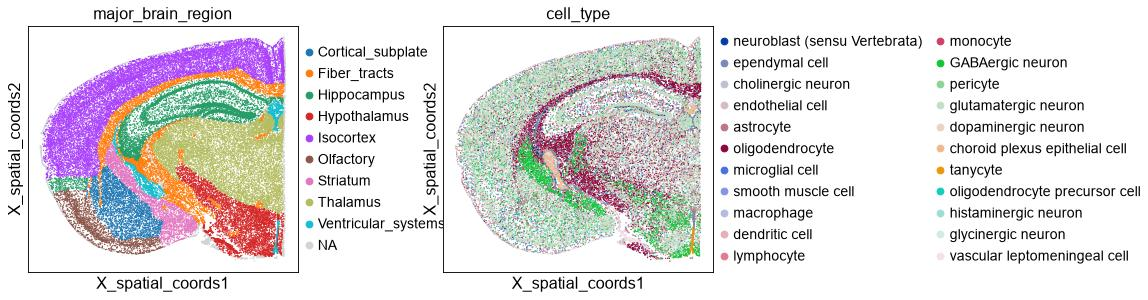

In [4]:
sc.pl.embedding(adata, basis="X_spatial_coords", color=["major_brain_region", "cell_type"], wspace=0.4, s=5)

## Basic Prep and QC

In [5]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=50)
sc.pp.filter_genes(adata, min_cells=20)

In [6]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Compute Inflow Score (Condensed Recap)

We briefly recompute the inflow score here, for a full walkthrough of bandwidth selection, spatial connectivity, and spatially variable gene (SVG) filtering, see the [inflow score tutorial](https://github.com/scverse/liana-py/blob/main/docs/notebooks/inflow_score.ipynb).

Since this dataset is mouse, we go straight to the `mouseconsensus` resource.

In [7]:
li.pp.spatial_neighbors(adata=adata, bandwidth=60, spatial_key="X_spatial_coords")

sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
adata = adata[:, svgs]

resource = li.rs.select_resource('mouseconsensus')

lrdata = li.mt.inflow(adata,
                      groupby='cell_type',
                      resource=resource,
                      nz_prop=0.001,  # keep rarely-expressed features; the 1% filter below handles sparsity
                      use_raw=False)
lrdata.shape

(46451, 1770)

---
### Quality control: inspect the inflow score before factorization

MOFA-Flex works best on roughly continuous, Gaussian-like features, but the inflow score is a spatially-weighted, cell-type-masked ligand × receptor product — so it is **zero-inflated and heavy-tailed**, and a few rare, spatially-clustered sender types produce features that are non-zero in only a handful of cells. These features destabilize the factorization (extreme factor scores, outlier-driven UMAPs); the [inflow debugging notebook](inflow_debug.ipynb) works through why `log1p` on the input does not prevent this.

It is therefore worth inspecting the score *before* training, to guide the inflow parameters:
- a strongly left-shifted **non-zero fraction** suggests widening the spatial `bandwidth` (each cell then integrates ligand from more neighbours) or raising `nz_prop`;
- persistently ultra-sparse features can be dropped with a **minimum non-zero-fraction filter** (or a higher `min_features` in `lrdata_to_mudata`) so they don't dominate the model.

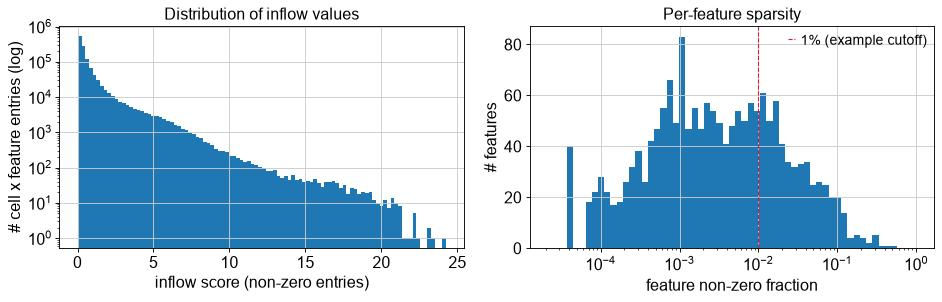

median feature non-zero fraction: 0.0026
features non-zero in <1% of cells: 71%


In [8]:
# Feature-level QC of the inflow score *before* factorization. MOFA-Flex assumes roughly
# continuous, Gaussian-ish features; the inflow score is instead zero-inflated and heavy-tailed
# (a spatially-weighted, cell-type-masked ligand x receptor product). `nonzero_fraction` is
# computed by `inflow` and stored in `lrdata.var`.
values = lrdata.X.data                        # non-zero inflow scores
nzf = lrdata.var["nonzero_fraction"].values   # fraction of cells carrying each feature
threshold = 0.01

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (1) Distribution of inflow scores (non-zero entries): most mass sits near zero, long right tail.
axes[0].hist(values, bins=100)
axes[0].set_yscale("log")
axes[0].set_xlabel("inflow score (non-zero entries)")
axes[0].set_ylabel("# cell x feature entries (log)")
axes[0].set_title("Distribution of inflow values")

# (2) Per-feature sparsity: how many cells actually carry each feature. Features non-zero in only
# a handful of cells (rare, spatially-clustered senders) are the ones that destabilize the model.
axes[1].hist(nzf, bins=np.logspace(np.log10(nzf[nzf > 0].min()), 0, 60))
axes[1].set_xscale("log")
axes[1].set_xlabel("feature non-zero fraction")
axes[1].set_ylabel("# features")
axes[1].set_title("Per-feature sparsity")
axes[1].axvline(threshold, color="crimson", ls="--", lw=1, label=f"{threshold*100:.0f}% (example cutoff)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"median feature non-zero fraction: {np.median(nzf):.4f}")
print(f"features non-zero in <{threshold*100:.0f}% of cells: {(nzf < threshold).mean():.0%}")

In [9]:
# Filter to features that are non-zero in at least x% of cells. This is an example cutoff; the
lrdata = lrdata[:,lrdata.var['nonzero_fraction'] > threshold]
lrdata.shape

(46451, 510)

### Filter to spatially variable interactions.

In [10]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
lrdata = lrdata[:, svis]
lrdata.shape

(46451, 506)

---
## From AnnData to MuData

We need to reshape the inflow score AnnData into a MuData object, where each **sender cell type becomes a view**.

In [11]:
from liana.ms import lrdata_to_mudata

mdata = lrdata_to_mudata(lrdata, min_features=25, obs_keys=["cell_type", "major_brain_region"])
mdata

MuData object with n_obs × n_vars = 46451 × 470
  obs:	'cell_type', 'major_brain_region'
  9 modalities
    glutamatergic neuron:	46451 × 97
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      layers:	None
    GABAergic neuron:	46451 × 77
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      layers:	None
    oligodendrocyte precursor cell:	46451 × 43
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      layers:	None
    pericyte:	46451 × 28
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      layers:	None
    astrocyte:	46451 × 69
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      obsm:	'X_CCF', 'X_spatial_coords', 'X_umap'
      layers:	None
    vascular 

---
## Training MOFA-Flex

MOFA-Flex extends the standard MOFA framework with a **Gaussian Process (GP) factor prior**: instead of treating cells as exchangeable, the GP prior encodes spatial proximity, so nearby cells in tissue are expected to have similar factor values. This makes factors spatially interpretable rather than just statistically optimal.

Here we pair the GP factor prior with **Horseshoe weight prior** to promote sparsity in the features loading matrix, so each factor is driven by a small, coherent set of features.

Training can take significant time and memory depending on dataset size and `max_epochs`; for large datasets, consider running this as a background job or on a compute cluster outside the notebook rather than interactively.

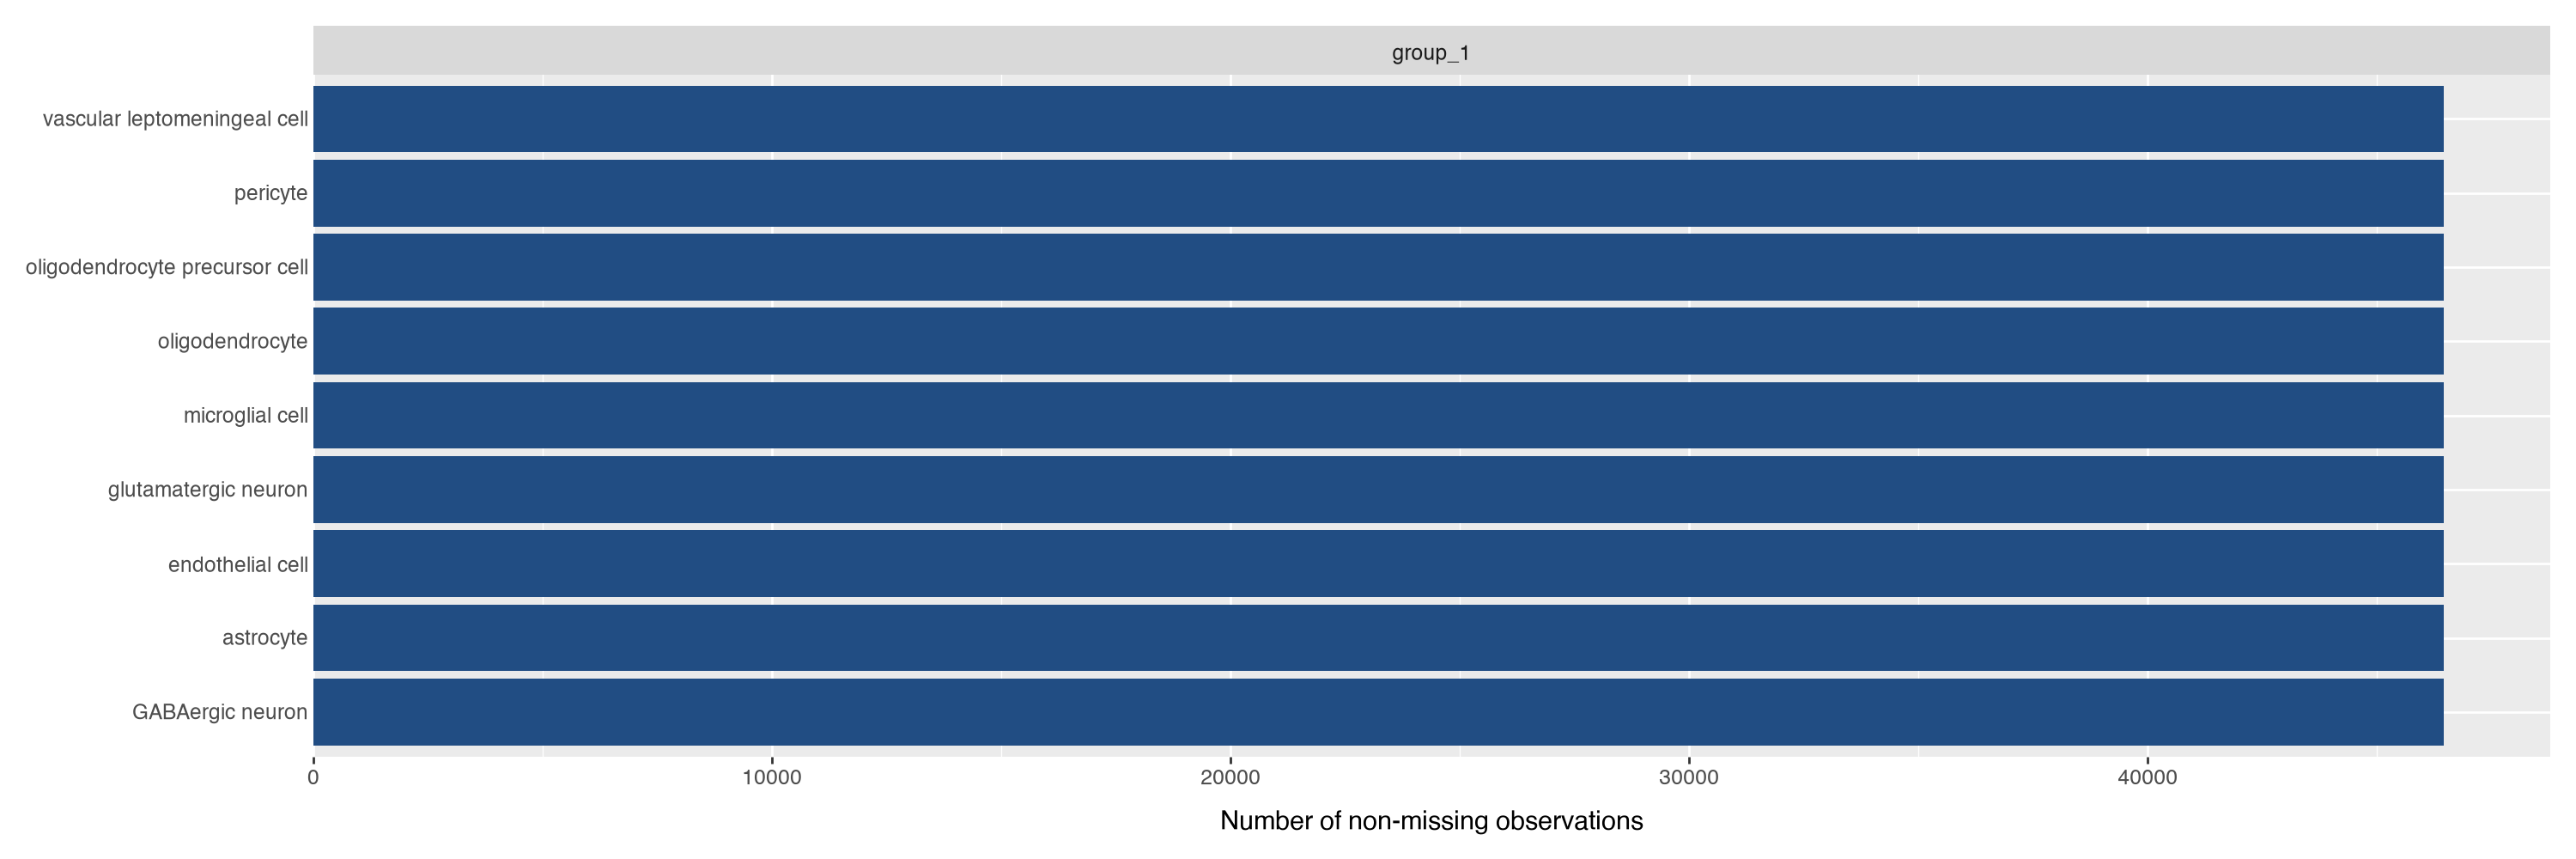

Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.


No likelihoods provided. Using inferred likelihoods: glutamatergic neuron: Normal; GABAergic neuron: Normal; oligodendrocyte precursor cell: Normal; pericyte: Normal; astrocyte: Normal; vascular leptomeningeal cell: Normal; endothelial cell: Normal; microglial cell: Normal; oligodendrocyte: Normal


Initializing factors using 'random' method...


/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/torch/utils/_device.py:103: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)



  0%|          | 0/1000 [00:00<?, ?epoch/s]

...


 23%|██▎       | 231/1000 [16:51<56:23,  4.40s/epoch, Loss=-1.01e+4]

Training converged after 231 epochs.



 23%|██▎       | 231/1000 [16:55<56:21,  4.40s/epoch, Loss=-1.01e+4]

Saving results to models/inflow_mofaflex_mouse_brain.hdf5...


/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mofaflex/_core/io.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.


In [12]:
os.makedirs("models", exist_ok=True)
save_path = "models/inflow_mofaflex_mouse_brain.hdf5"

# Training is deterministic here (see the reproducibility setup in the imports cell), but it is
# slow, so we fit once and reuse the saved model on subsequent runs (delete the file to retrain
# from scratch). The model is trained on GPU when available (see `device` above).
if not os.path.exists(save_path):
    model = mfl.terms.MofaFlex(
        n_factors=20,
        factor_prior=mfl.priors.GaussianProcess(
            covariates_mkey="X_spatial_coords",
            independent_lengthscales=True,
        ),
        weight_prior=mfl.priors.Horseshoe(),
        nonnegative_weights=False,
    )

    model.fit(
        mdata,
        batch_size=2048,
        n_particles=1,
        lr=0.005,
        max_epochs=1000,
        save_path=save_path,
        early_stopper_patience=50,
        seed=0,
        device=device,
    )
else:
    print(f"Reusing cached model at {save_path}")

---
## Model Quality Checks

Before interpreting factors biologically, we run two diagnostic checks:

1. **Factor correlation**: correlated factor pairs may encode the same signal, indicating the model could be simplified or that a biological program was split across multiple factors.
2. **Variance explained**: quantifies how much of the data variance each factor accounts for, per modality. Factors with near-zero R² are noise and will be removed in the next step.

We now load the fitted model back as a `MOFAFLEX` analysis object. This is the object all the downstream diagnostics and plotting functions expect, and it works regardless of whether the model was just trained above or loaded from cache (or trained earlier in a separate process).

In [13]:
model = mfl.MOFAFLEX.load(save_path)

### Latent Factor Correlation

Each factor captures an independent biological signal. Highly correlated factors (|r| > 0.6) suggest redundancy.

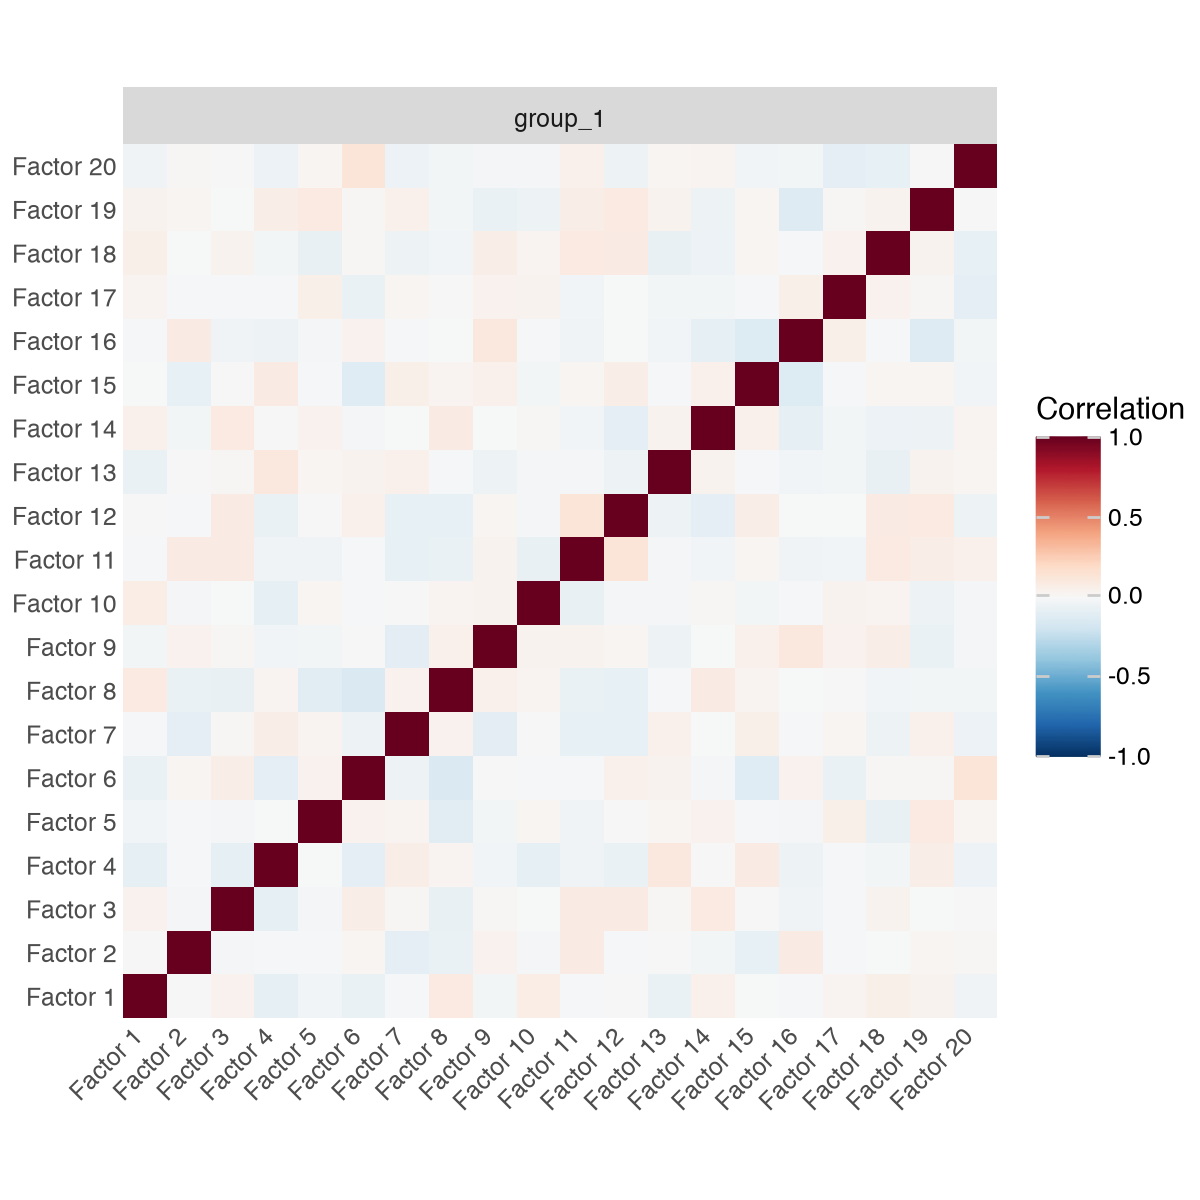

In [14]:
# Check for redundant factors: highly correlated factors may capture the same signal
mfl.pl.factor_correlation(model, figsize=(6, 6))

### Variance Explained per Modality

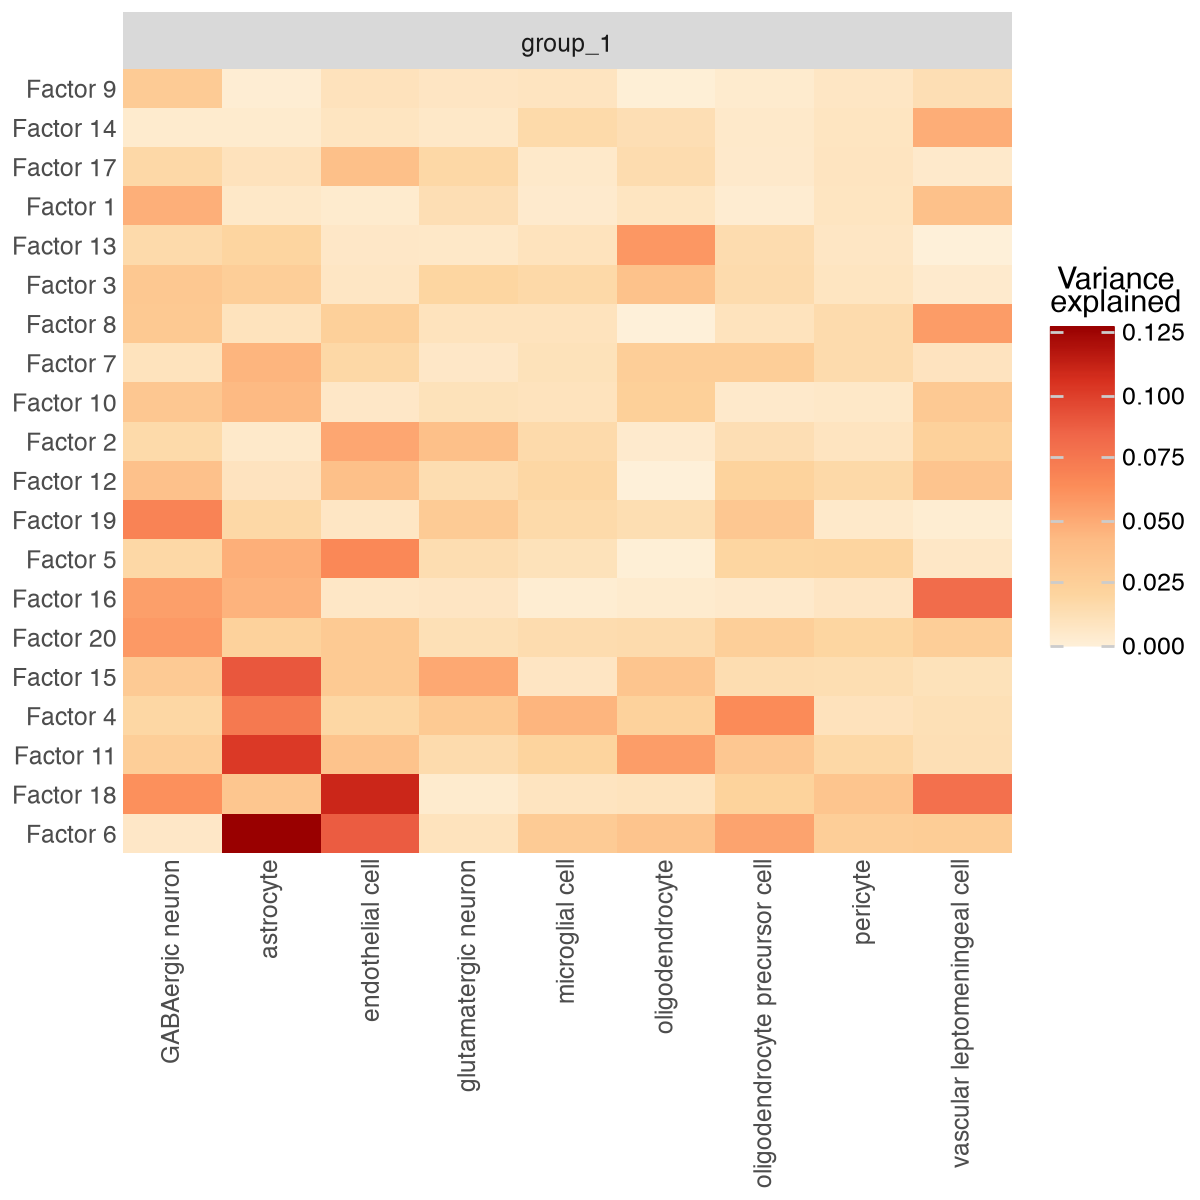

In [15]:
# How much variance does each factor explain?
# Helps identify which factors are biologically meaningful vs noise
mfl.pl.variance_explained(model, figsize=(6, 6))

### Variance Explained per Sender View

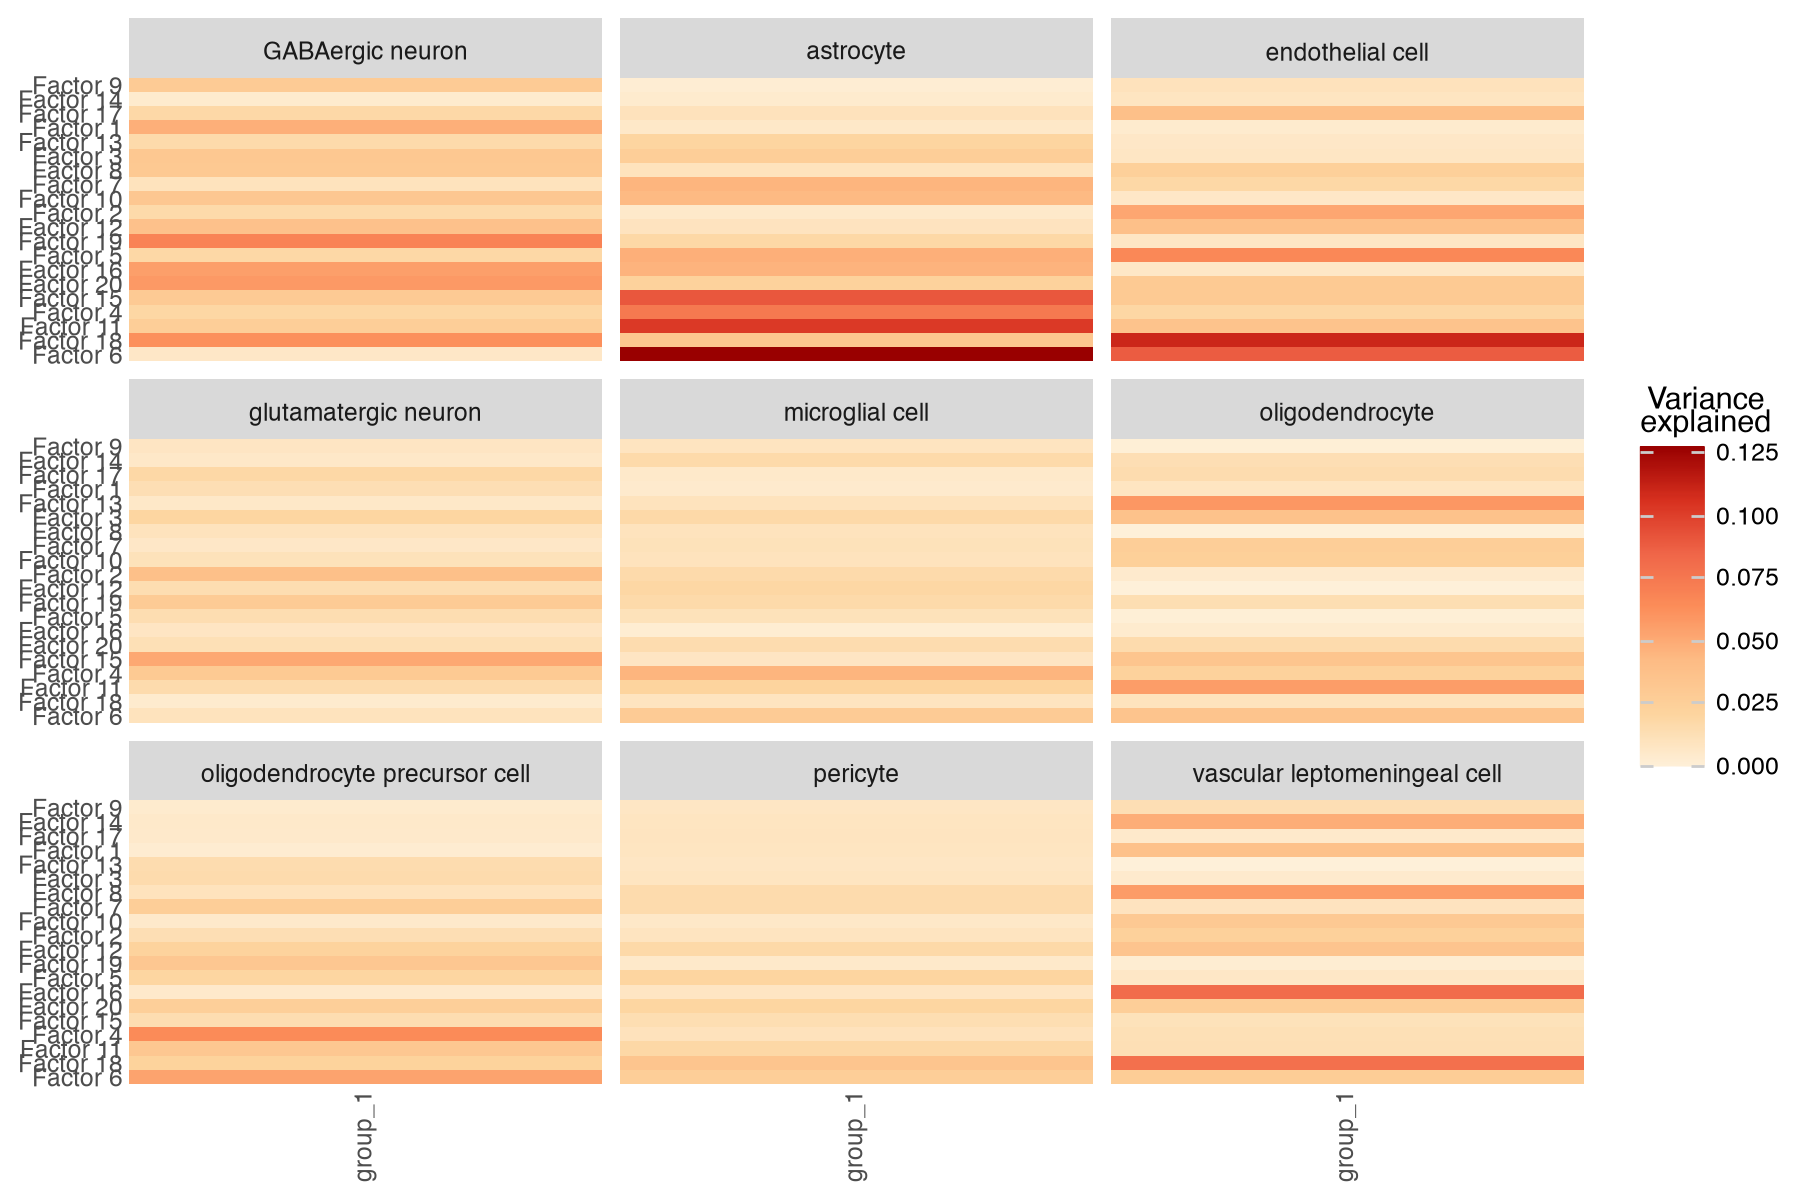

In [16]:
# Break the same variance down per sender view (each modality = one sender cell type).
# This shows *where* a factor draws its signal from: a factor loading heavily on a single
# view is a sender-specific program, while one spread across many views is a shared axis.
mfl.pl.variance_explained(model, group_by="view", figsize=(9, 6))

---
## Selecting Informative Factors

Not all factors are equally informative. We keep every factor that clears a minimum R² floor (2%) in at least one modality — the standard definition of an "active" (non-noise) factor — and rank the survivors by total R² for display order.

Two things are worth keeping in mind when reading the factors that survive this filter. Some of them are **heavy-tailed**: the score is essentially flat across the whole section and then spikes — by *tens* of standard deviations — in a small, spatially-clustered population. These are genuine signals, but they are driven by a handful of cells rather than a broad program, so they are easy to over-interpret. Their practical side effect — a few outlier cells hijacking the neighbour graph and washing out colour scales — is handled by clipping the factor scores before clustering below.

In [17]:
adata

View of AnnData object with n_obs × n_vars = 46451 × 1002
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'major_brain_region_colors', 'cell_type_colors', 'log1p', 'moranI'
    obsm: 

In [18]:
r2_df = model.get_r2(type="term", term=None)  # columns: group, view, component, R2

# Keep every factor that clears a 2% R2 floor in at least one view/group -- the standard
# "active" / non-noise factor definition. Rank by total R2 for display order only.
r2_by_factor = r2_df.groupby("component")["R2"]
factors = r2_by_factor.sum()[r2_by_factor.max() >= 0.02].sort_values(ascending=False).index.tolist()

# get_factors() returns dict[str, pd.DataFrame] (samples x factors), not AnnData
factor_adata = ad.AnnData(model.get_factors()["group_1"])[:, factors].copy()
factor_adata.obsm["spatial"] = adata.obsm["X_spatial_coords"].copy()

shared_obs = adata.obs_names.intersection(factor_adata.obs_names)
factor_adata.obs.loc[shared_obs, ["cell_type", "major_brain_region"]] = adata.obs.loc[
    shared_obs, ["cell_type", "major_brain_region"]
]

In [19]:
factor_adata

AnnData object with n_obs × n_vars = 46451 × 20
    obs: 'cell_type', 'major_brain_region'
    obsm: 'spatial'
    layers: None (.X)

---
## Exploring Factors: Feature Weights and Spatial Activity

Each MOFA-Flex factor has two complementary representations:

- **Feature weights** (loadings): which LR-pairs drive the factor. Larger absolute weights indicate a stronger association between that feature and the factor.
- **Factor scores**: the per-cell value of the factor. Since the GP prior was used, these scores should vary smoothly across the tissue section.

### Top Feature Weights per Factor

The plot below shows the 5 features (LR pairs) with the largest absolute weight for each factor. Features appearing in multiple factors may represent shared biological themes.

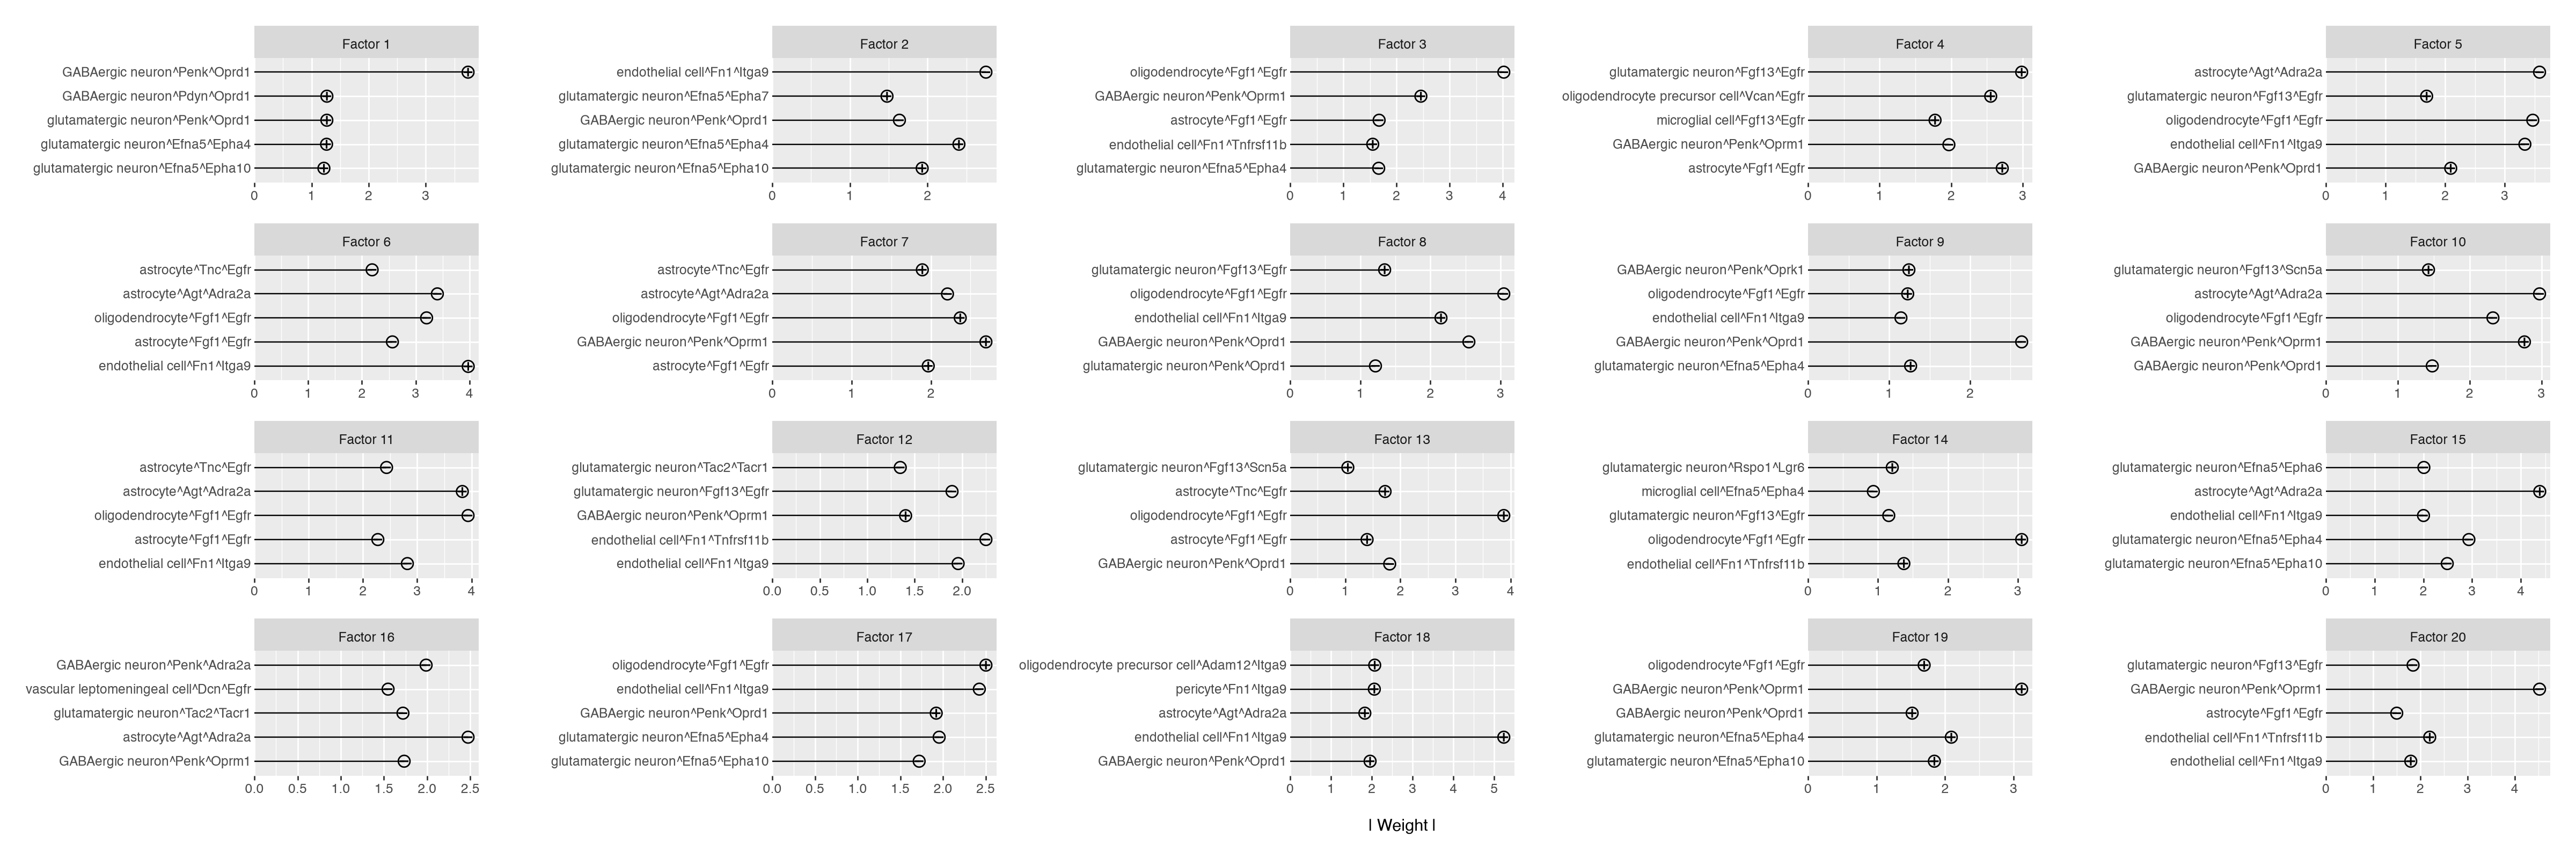

In [20]:
# For each factor, show the 5 features with the largest absolute weight.
# High-weight features are the molecular signals most strongly associated with that factor.
mfl.pl.top_weights(model, n_features=5, factors=None, figsize=(24, 8), nrow=None, ncol=None)

---
## Cell Clustering in Factor Space

We build a k-nearest-neighbour (k-NN) graph directly on the factor matrix. This means cells are grouped by their communication program, rather than by raw inflow score similarity.

In [21]:
# Build a k-NN graph in factor space.
# Guard against the heavy tail first: a few rare, spatially-clustered cells sit tens of SDs out
# on some factors and would otherwise dominate the Euclidean k-NN
# and collapse everything else into a blob. We z-score each factor and clip to +/-5 SD for the
# graph only; `.X` keeps the raw scores for the score overlays and per-region summaries below.
z = (factor_adata.X - factor_adata.X.mean(0)) / factor_adata.X.std(0)
factor_adata.obsm["X_clipped"] = np.clip(z, -5, 5)
sc.pp.neighbors(factor_adata, use_rep="X_clipped")

In [22]:
# Embed the factor-space k-NN graph in 2D for visualization
sc.tl.umap(factor_adata, neighbors_key='neighbors')

In [23]:
# Cluster cells by communication program (low resolution -> few, coarse clusters)
sc.tl.leiden(factor_adata, resolution=0.4, flavor="igraph")

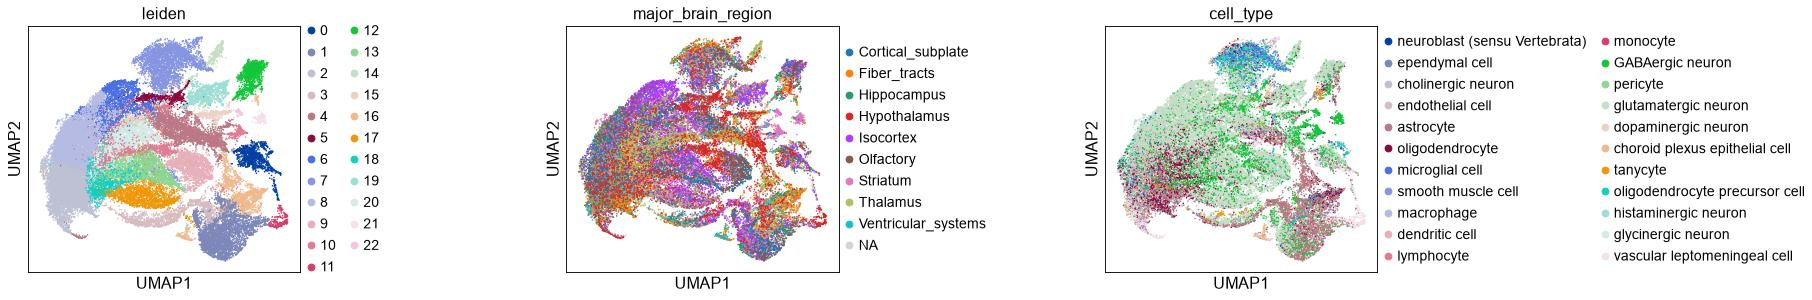

In [24]:
# Compare unsupervised Leiden clusters against known annotations
sc.pl.umap(
    factor_adata,
    color=[ "leiden", "major_brain_region", "cell_type"],
    size=8,
    wspace=0.8
)

Overlay individual factor scores on the same UMAP to see which factors drive which clusters. Here we preview the two factors dissected in detail below — **Factor 1** and **Factor 4**.

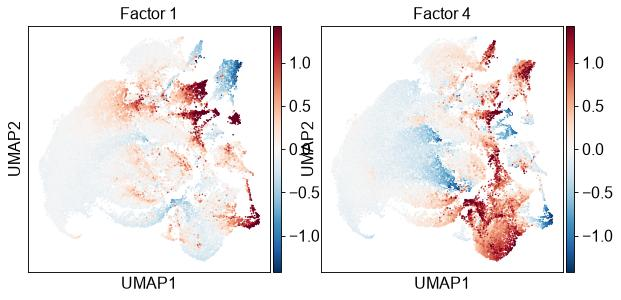

In [25]:
# Preview the two factors we dissect below (Factors 1 and 4) in UMAP space.
# Robust symmetric colour limits (|value| at the 99th percentile, computed over all
# factors) so the heavy-tailed outliers don't wash out the diverging colour scale.
preview_factors = ["Factor 1", "Factor 4"]
absmax = np.nanpercentile(np.abs(factor_adata[:, factors].X), 99)
sc.pl.umap(
    factor_adata,
    color=preview_factors,   # factor scores as color
    cmap="RdBu_r",
    vcenter=0, vmin=-absmax, vmax=absmax,
    size=8,
    ncols=2,
    wspace=0.1,
)

Check whether the Leiden clusters form spatially coherent regions in tissue

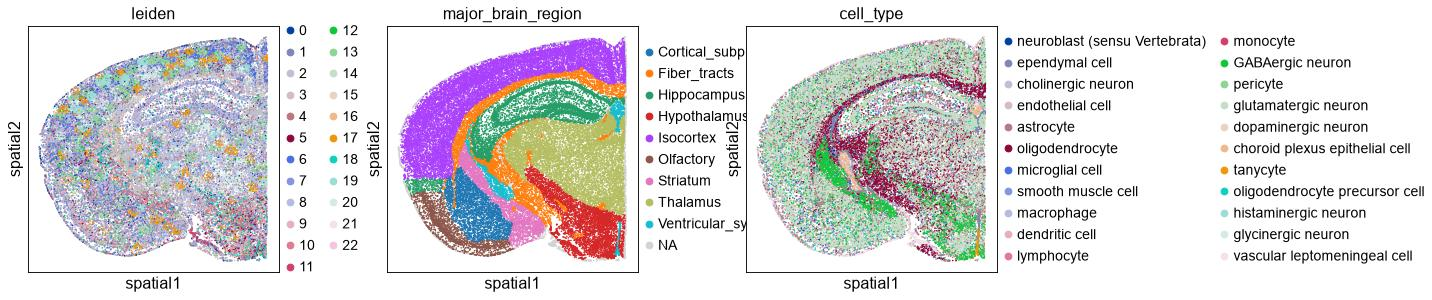

In [26]:
sc.pl.embedding(
    factor_adata,
    basis="spatial",
    color=["leiden", "major_brain_region",  "cell_type"],
    s=8,
    wspace=0.3,
    show=True
)

Clustering directly on the raw inflow scores produces dozens of small, spatially fragmented clusters, whereas factor space yields far coarser and more spatially coherent structure. With ~1,600 noisy `sender^ligand^receptor` features and no spatial prior, PCA has no reason to recover spatially smooth structure; MOFA-Flex's Horseshoe prior sparsifies the loadings and its Gaussian Process prior smooths the factors over space.

Two caveats keep this honest. First, these communication programs are **continuous spatial gradients, not discrete cell types** — so the Leiden clusters are best read as coarse tissue *domains*, not the clean, well-separated islands you would get clustering on gene expression. Second, a few programs are carried by **rare, spatially-concentrated populations**: their scores spike far above the rest of the section (the heavy tail we clipped before building the graph), so — left unclipped — a handful of cells would dominate both the neighbour graph and the colour scale.

---
## Dissecting a Factor: From Loadings to Interactions

So far we have seen *which* factors are informative and *where* they are active. To interpret a factor biologically we need to know *which cell-cell interactions drive it* — and, ideally, connect the abstract loadings back to the actual communication signal.

To do that we build a small bridge between the two packages:

- **MOFA-Flex loadings** tell us which `sender^ligand^receptor` features a factor weights on, and with which sign.
- **Raw inflow scores** tell us the actual magnitude of each interaction, and — because every cell is a receiver with a known `cell_type` — let us recover a **receiver (target) cell type** that the loadings alone do not carry.

Merging the two gives a liana-style `source → target` interaction table per factor, which we can hand straight to LIANA+'s `dotplot` and `circle_plot`.

> **A note on sign.** A MOFA factor is an *axis*: its sign is arbitrary, so a positive vs negative loading only tells you which of the two opposite poles an interaction sits on, not "more" vs "less". Read the colour below as *which pole*, and lean on the top-weights bar plot and the spatial maps to anchor the interpretation.

In [27]:
# --- Bridge: MOFA-Flex weights + raw inflow -> a liana-style interaction table ---

# 1. Loadings: signed weight of every `sender^ligand^receptor` feature on each factor.
#    `get_variable_loadings` accepts MOFA-Flex weights directly and splits the feature
#    names into source / ligand_complex / receptor_complex.
loadings = li.ms.get_variable_loadings(
    loadings=model.get_weights(),
    variable_sep="^",
    var_names=["source", "ligand_complex", "receptor_complex"],
)

# 2. Mean inflow per receiver cell type -> a source (sender) x target (receiver) x LR table.
#    Each cell in `lrdata` is a receiver, so grouping by its `cell_type` recovers the target axis.
inflow_means = (
    lrdata.to_df()
    .groupby(lrdata.obs["cell_type"], observed=True)
    .mean()
    .T
    .reset_index(names="feature")
    .melt(id_vars="feature", var_name="target", value_name="inflow")
)
inflow_means[["source", "ligand_complex", "receptor_complex"]] = (
    inflow_means["feature"].str.split("^", expand=True)
)


def factor_interactions(factor, top_n=12):
    """Top-|weight| interactions of `factor`, annotated with mean inflow per receiver type."""
    keys = ["source", "ligand_complex", "receptor_complex"]
    lo = loadings[[*keys, factor]].rename(columns={factor: "loading"})
    lo = lo.reindex(lo["loading"].abs().sort_values(ascending=False).index).head(top_n)
    return lo.merge(inflow_means[[*keys, "target", "inflow"]], on=keys, how="left")


# Example factor(s) to dissect. `factors` is the retained set selected above; here we pick two
# independent, biologically distinct programs to contrast (swap in `factors[:2]` to just take
# the top-ranked ones, or any factor names you like).
focus_factors = ["Factor 1", "Factor 4"]
focus_factors

['Factor 1', 'Factor 4']

The top-weights bar plot shown earlier lists the features of each factor separately. LIANA+'s `dotplot` lets us put the focus factors **side by side**: for the union of their top-weighted interactions, we can compare at a glance which pole (colour) and how strongly (size) each interaction loads on each factor — and read off which sender each interaction belongs to (facets).

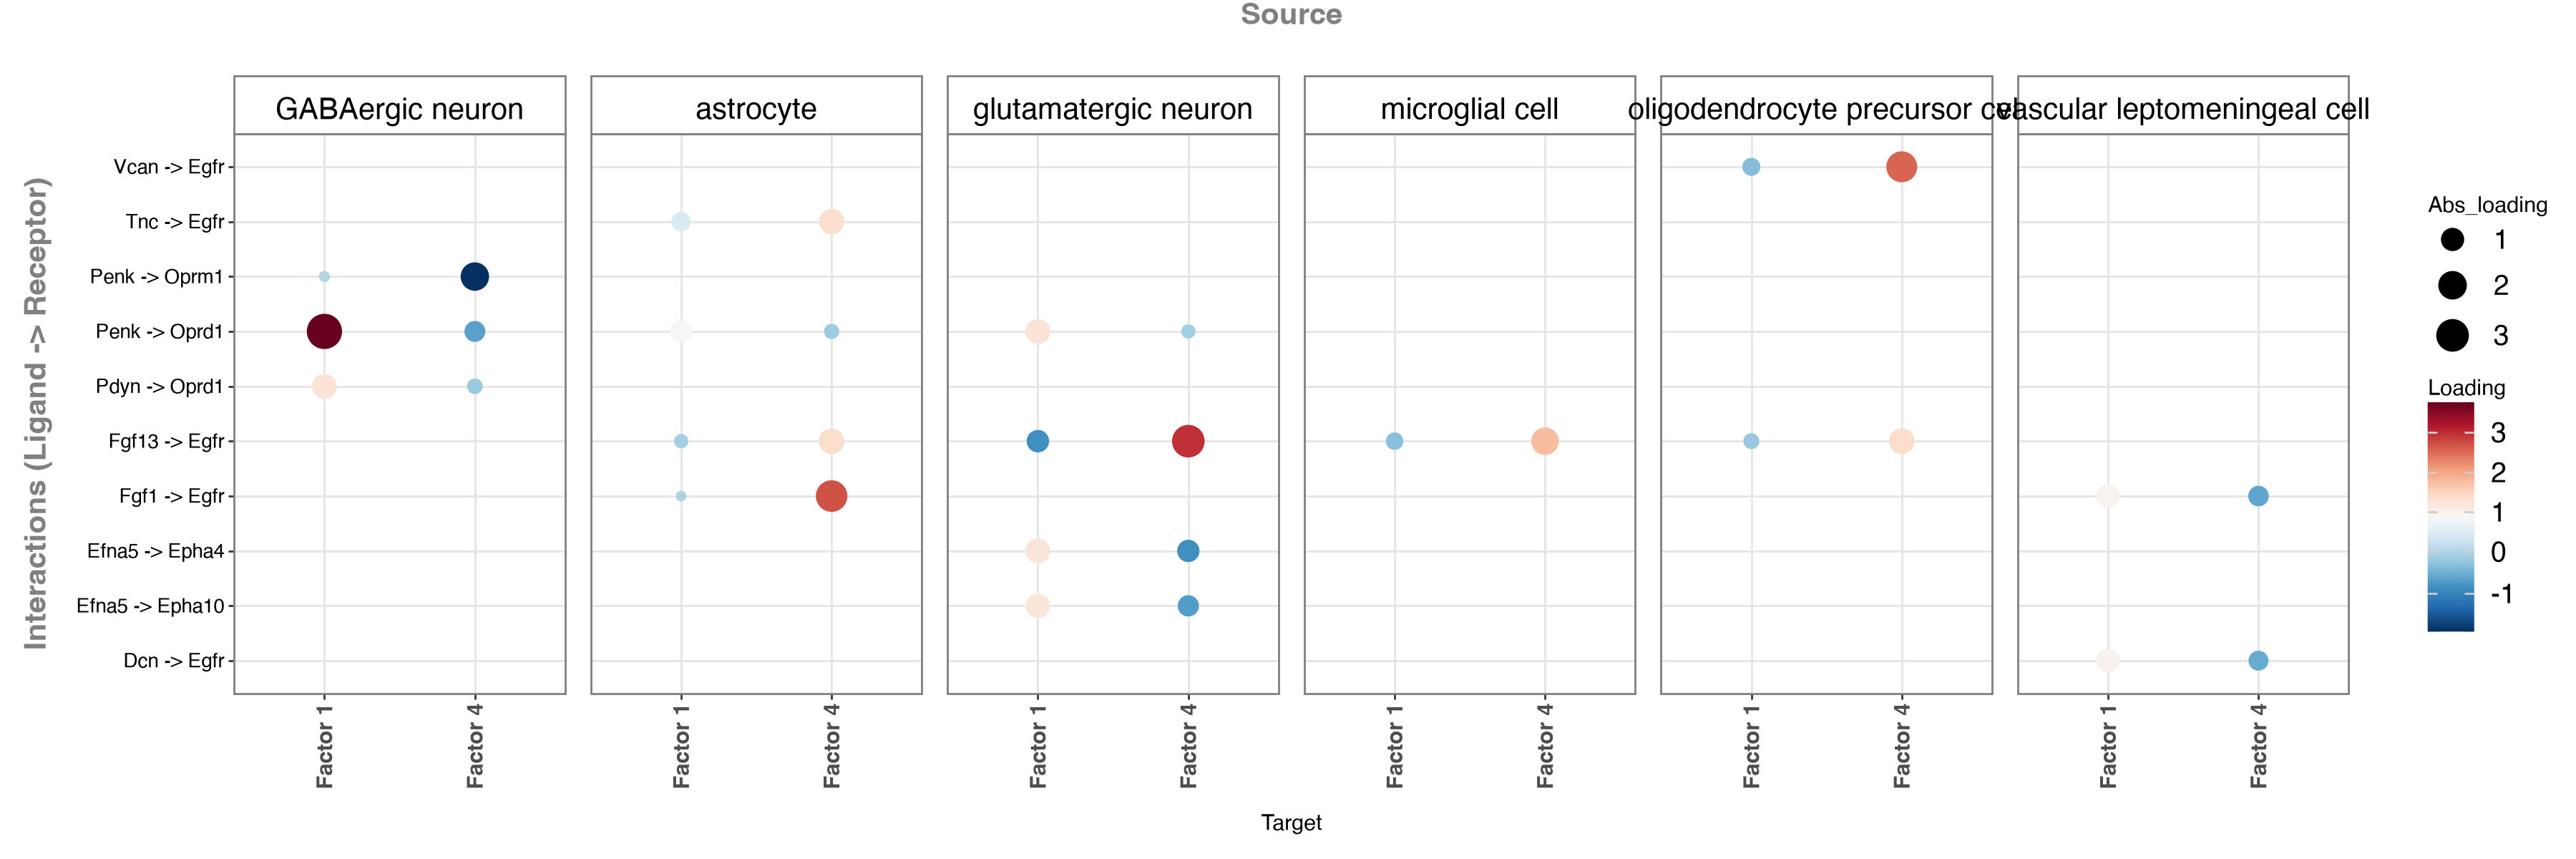

In [28]:
# Dotplot comparing how the top interactions load across the focus factors.
#   rows   = ligand -> receptor interaction
#   facets = sender (source) cell type
#   x      = factor
#   colour = signed loading (which pole of the factor), size = |loading|
keys = ["source", "ligand_complex", "receptor_complex"]

# union of each focus factor's top-weighted interactions
top_feats = pd.concat(
    [loadings.reindex(loadings[f].abs().sort_values(ascending=False).index).head(8)[keys]
     for f in focus_factors]
).drop_duplicates()

loadings_long = (
    loadings.merge(top_feats, on=keys)
    .melt(id_vars=keys, value_vars=focus_factors, var_name="target", value_name="loading")
)
loadings_long["abs_loading"] = loadings_long["loading"].abs()

li.pl.dotplot(
    liana_res=loadings_long,
    colour="loading",
    size="abs_loading",
    cmap="RdBu_r",
    figure_size=(18, 6),
)

The dotplot compares loadings but says nothing about the actual communication magnitude or its sender→receiver structure. LIANA+'s `circle_plot` adds exactly that: each node is a cell type and edges run from sender to receiver, weighted by the mean inflow of the factor's top interactions — making it easy to see which cell types anchor each program.

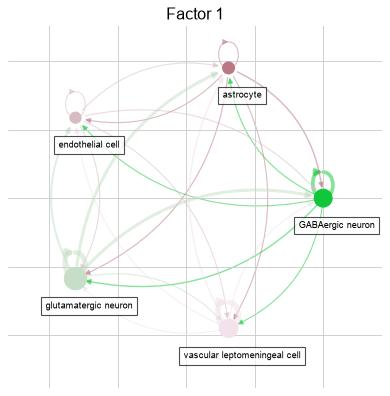

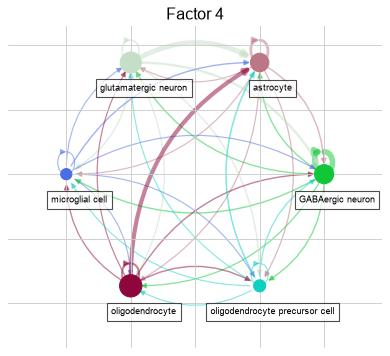

In [29]:
# Circle plot: sender -> receiver network for a factor's top interactions.
# Node = cell type; edge = mean inflow between a sender and receiver type,
# aggregated over the factor's top-weighted ligand-receptor pairs.
for f in focus_factors:
    lrdata.uns["liana_res"] = factor_interactions(f, top_n=10)
    ax = li.pl.circle(
        lrdata,
        groupby="cell_type",
        source_key="source",
        target_key="target",
        score_key="inflow",
        pivot_mode="mean",
        figure_size=(6, 6),
    )
    ax.set_title(f)
    plt.show()

The two focus factors capture very different biology. **Factor 1** is dominated by GABAergic-neuron–derived proenkephalin (`Penk`) signalling onto the δ- and μ-opioid receptors `Oprd1` / `Oprm1` (with related prodynorphin `Pdyn`) — an enkephalinergic neuropeptide program broadcast largely by inhibitory neurons, with a secondary ephrin (`Efna5`→`Eph`) component. **Factor 4**, by contrast, is a trophic / extracellular-matrix program: fibroblast-growth-factor and matrix-proteoglycan signals — `Fgf1`, `Fgf13` and versican (`Vcan`) — converging on the EGF receptor `Egfr`, emanating from glutamatergic neurons, oligodendrocyte-precursor cells, astrocytes and microglia rather than from the `Penk`-expressing inhibitory neurons.

The two programs share essentially no ligand-receptor pairs and are near-independent (|r| ≈ 0.07; see the factor-correlation diagnostic above): two distinct communication programs carried by distinct sender populations — inhibitory neurons versus a distributed neuronal / glial FGF–ECM compartment. The dotplot and circle plot make both the molecular content and the sender→receiver structure explicit.

_(Recall the sign caveat: a factor's polarity is arbitrary, so read the loading colours as "which pole", not "up/down".)_

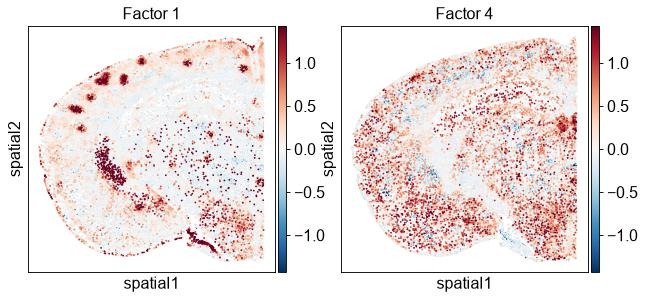

In [30]:
# Spatial activity of the same focus factors (reuses `focus_factors` from above).
vals = np.hstack([factor_adata[:, f].X.flatten() for f in focus_factors])
p_low, p_high = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
absmax = max(abs(p_low), abs(p_high))
norm = colors.TwoSlopeNorm(vcenter=0, vmin=-absmax, vmax=absmax)

sc.pl.embedding(
    factor_adata,
    basis="spatial",
    color=focus_factors,
    cmap="RdBu_r",
    norm=norm,
    s=10,
    ncols=2,
    wspace=0.15,
    show=True
)

The two programs also occupy different territory. **Factor 1** is overwhelmingly a **striatal** program — by far the single largest regional effect — where the `Penk`-expressing GABAergic (medium-spiny) neurons are dense, with weak, opposite-pole signal in the thalamus, hippocampus and ventricular system. **Factor 4** instead patterns an **olfactory / cortical-subplate ↔ fiber-tract / isocortical** axis, consistent with its distributed neuronal and glial FGF–ECM origin. The bar plot below reads these hotspots off the annotated regions directly.

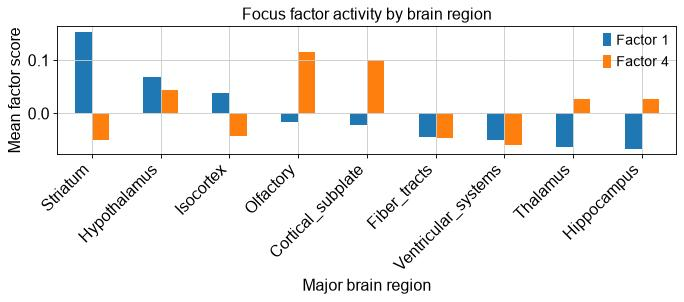

In [31]:
region_means = (
    factor_adata.to_df()[focus_factors]
    .groupby(factor_adata.obs["major_brain_region"], observed=True)
    .mean()
    .sort_values(focus_factors[0], ascending=False)
)

region_means.plot(kind="bar", figsize=(9, 4))
plt.ylabel("Mean factor score")
plt.xlabel("Major brain region")
plt.title("Focus factor activity by brain region")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## Package Versions

For reproducibility, we report the versions of the key packages used to run this tutorial.

In [32]:
print(f"mofaflex: {mfl.__version__}")
print(f"liana:    {li.__version__}")

mofaflex: 0.1.0.post2.dev156+g1f97fa0c4
liana:    1.10.1.dev21+g6e4302f54.d20260907


---

<div style="border:2px solid #790e0eff; background-color:#e3f2fd; padding:12px; border-radius:8px; font-size:1.1em; margin:10px 0;">
<strong>Note:</strong> This tutorial is part of an ongoing <b>LIANA+</b> extension (Alsayah et al., in prep). Feedback welcome!
</div>